# Problem

**State Space**

The state space consists of two discrete states:
$$
\mathcal{X} = \{0, 1\}.
$$

These can be interpreted as two different situations or system configurations, for instance, a “low-performance” state (0) and a “high-performance” state (1).

 **Action Space**

The action space consists of two discrete actions:
$$
\mathcal{A} = \{0, 1\}.
$$

These actions can be thought of as two control options available to the agent — for example:

* **Action 0**: Conservative or “stay” action (keeps the system near state 0)
* **Action 1**: Aggressive or “move” action (pushes the system toward state 1)

**Reward Function**

The reward is explicitly given by:
$$
r(x,a) = x + a.
$$

This means:
* Rewards increase with higher actions.
* Being in the “high” state (1) also provides additional reward.

**Transition Function**

Deterministic transition dynamics:

* If the agent takes **action 0**, it always transitions to state 0.
* If the agent takes **action 1**, it always transitions to state 1.

In tabular form:

| Current (x,a) | P(x′=0) | P(x′=1) |
| ------------- | ------- | ------- |
| (0,0)         | 1.0     | 0.0     |
| (0,1)         | 0.0     | 1.0     |
| (1,0)         | 1.0     | 0.0     |
| (1,1)         | 0.0     | 1.0     |

In [1]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path

import numpy as np
import torch

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def tensor64(data):
    return torch.as_tensor(data, dtype=torch.float64, device=DEVICE)


def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())

# Clean datasets/results folders
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Example dataset path for saving/loading new clean datasets
dataset_path = DATASETS_DIR / "dataset.pt"

# Add src to Python path
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.data_collection_clean import DiscreteDataBuffer, DatasetAnalyzer
from rl_methods.fogas_clean import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
    FOGASParameters,
)

# Tabular Features

## Definition

**Feature Map** 

We use a one-hot feature representation over state–action pairs.  
Each feature corresponds to a unique \((x,a)\) combination.

The feature map is defined as:
$$
\phi(x,a) \in \mathbb{R}^4
$$

with the ordering:
$$
(0,0) \rightarrow e_0,\quad
(0,1) \rightarrow e_1,\quad
(1,0) \rightarrow e_2,\quad
(1,1) \rightarrow e_3
$$

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$

with weight vector:
$$
\omega =
\begin{bmatrix}
0 \\
1 \\
1 \\
2
\end{bmatrix}.
$$

**Transition Weights**

The transition model is also linear in the features:
$$
p(x' \mid x,a) = \phi(x,a)^\top \psi(x').
$$

The transition weight vectors are:
$$
\psi(0) =
\begin{bmatrix}
1 \\
0 \\
1 \\
0
\end{bmatrix},
\quad
\psi(1) =
\begin{bmatrix}
0 \\
1 \\
0 \\
1
\end{bmatrix}.
$$


## Testing

In [3]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)
gamma_2d = 0.99
x_0 = 0

def phi(state, action):
    vec = torch.zeros(4, dtype=torch.float64)
    vec[int(state) * 2 + int(action)] = 1.0
    return vec

omega = tensor64([0, 1.0, 1.0, 2.0])

psi = {
    0: tensor64([1.0, 0, 1.0, 0]),
    1: tensor64([0, 1.0, 0, 1.0]),
}

mdp = DiscreteMDP(
    states=states_2d,
    actions=actions_2d,
    gamma=gamma_2d,
    x0=x_0,
    omega=omega,
    psi=psi,
    phi=phi, 
)

planner = Planner(mdp)

### Oracle

In [4]:
solver = FOGASOracleSolver(
    planner=planner,
    phi=phi,
    cov_matrix="identity",
    print_params=True,
    T=400,
    seed=SEED,
    device=DEVICE,
)

evaluator = FOGASEvaluator(solver, planner=planner)

optimizer = FOGASHyperOptimizer(
    solver=solver,
    evaluator=evaluator,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 1000,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      4627564.263195183
T (iterations):                400   (overridden → 400)

FOGAS Hyperparameters
---------------------
alpha:                        0.000294
rho:                            6.969724
eta:                            0.000024
D_theta:                    20.000000
beta (ridge):             0.000625
D_pi (derived):           2.354820




FOGAS hyperopt:   0%|          | 0/31 [00:00<?, ?candidate/s]

FOGAS hyperopt: 100%|██████████| 31/31 [00:43<00:00,  1.42s/candidate, stage=random:joint, metric=-5.02, best=-5.02]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: smart
Smart mode: joint | Strategy: random
Parameters: ('alpha', 'D_theta', 'rho', 'eta')
Evaluated candidates: 31
Best metric: -5.01942
Best params: alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.4720e+00

Top 5 candidates:
1. metric=-5.01942 | stage=random:joint | alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.4720e+00
2. metric=-5.01942 | stage=random:joint | alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.4720e+00
3. metric=-5.01942 | stage=random:joint | alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.4720e+00
4. metric=-5.01942 | stage=random:joint | alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.4720e+00
5. metric=-5.01942 | stage=random:joint | alpha=3.6353e-04, rho=6.1498e-02, eta=2.3614e+00, T=400, D_theta=2.3877e+01, D_pi=3.

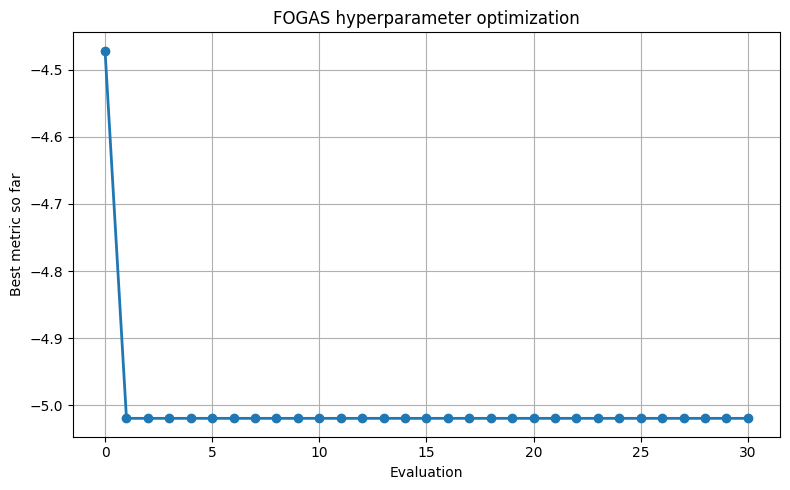

In [14]:
summary = optimizer.optimize(
    mode="smart",
    strategy="random",
    smart_mode="joint",
    parameters=("alpha", "D_theta", "rho", "eta"),
    coarse_points=20,
    random_candidates=30,
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True
)

alpha_star = summary["best_params"]["alpha"]
rho_star = summary["best_params"]["rho"]
eta_star = summary["best_params"]["eta"]
D_theta_star = summary["best_params"]["D_theta"]

In [20]:
solver.run(alpha=alpha_star, eta=eta_star, rho=rho_star, T = 10000, tqdm_print=True)
evaluator.compare_value_functions()

FOGAS Oracle: 100%|██████████| 10000/10000 [00:03<00:00, 2999.81it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  198.301288 | delta = -6.987120e-01
State 1: V*(x) =  200.000000 | V^pi(x) =  199.300466 | delta = -6.995339e-01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  196.318275 | delta = -6.917249e-01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  198.307461 | delta = -6.925385e-01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  197.318275 | delta = -6.917249e-01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  199.307461 | delta = -6.925385e-01

Norm diagnostics:
||V^pi - V*||_2 = 9.887093e-01
||Q^pi - Q*||_2 = 1.384264e+00




### Dataset creation

In [22]:
dataset_path = DATASETS_DIR / "2states.csv"

collector = DiscreteDataBuffer(
    mdp=mdp,
    max_steps=100,
    seed=SEED,
)

df = collector.collect(
    policy="random",
    n_steps=500,
    extra_terminal_steps=3,
    save_path=str(dataset_path),
    verbose=True,
)

Collected 500 transitions over 5 episodes.
Policy distribution:
policy_id
0    1.0
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
x0    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/2states.csv


### Empirical

In [29]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(DATASETS_DIR / "2states.csv"),
    print_params=True,
    seed=SEED,
    device=DEVICE,
    T = 1000,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 1000,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/2states.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             2
Num actions A:            2
Feature dim d:            4
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      231.37821315975916
T (iterations):                1000   (overridden → 1000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000186
rho:                            1031.262332
eta:                            0.000015
D_theta:                    20.000000
beta (ridge):             0.000250
D_pi (derived):           3.723297




Trying same optimal hyperparameters found for the oracle.

In [30]:
solver_e.run(
    alpha=alpha_star,
    eta=eta_star,
    rho=rho_star,
    D_theta=D_theta_star,
    T = 20000,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS:   0%|          | 0/20000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 20000/20000 [00:06<00:00, 3109.54it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  148.080399 | delta = -5.091960e+01
State 1: V*(x) =  200.000000 | V^pi(x) =  148.752180 | delta = -5.124782e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  146.599595 | delta = -5.041040e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  148.264659 | delta = -5.073534e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  147.599595 | delta = -5.041040e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  149.264659 | delta = -5.073534e+01

Norm diagnostics:
||V^pi - V*||_2 = 7.224365e+01
||Q^pi - Q*||_2 = 1.011463e+02


Solver average return: 6.645641517
Optimal average return: 8.801990020000002
Gap: 2.156348503000002


FOGAS hyperopt:   0%|          | 0/192 [00:00<?, ?candidate/s]

FOGAS hyperopt: 100%|██████████| 192/192 [05:48<00:00,  1.81s/candidate, stage=grid, metric=-6.49, best=-6.57]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 192
Best metric: -6.57498
Best params: alpha=3.0000e-03, rho=1.0000e+01, eta=3.0000e-04, T=1000, D_theta=5.0000e+00, D_pi=1.5000e+01

Top 5 candidates:
1. metric=-6.57498 | stage=grid | alpha=3.0000e-03, rho=1.0000e+01, eta=3.0000e-04, T=1000, D_theta=5.0000e+00, D_pi=1.5000e+01
2. metric=-6.54953 | stage=grid | alpha=3.0000e-03, rho=1.0000e+01, eta=3.0000e-04, T=1000, D_theta=1.0000e+01, D_pi=3.0000e+01
3. metric=-6.52875 | stage=grid | alpha=3.0000e-03, rho=1.0000e+01, eta=1.0000e-05, T=1000, D_theta=1.0000e+01, D_pi=3.0000e+01
4. metric=-6.51701 | stage=grid | alpha=3.0000e-03, rho=1.0000e-02, eta=1.0000e-05, T=1000, D_theta=5.0000e+00, D_pi=1.5000e+01
5. metric=-6.51701 | stage=grid | alpha=3.0000e-03, rho=1.0000e-01, eta=1.0000e-05, T=1000, D_theta=5.0000e+00, D_pi=1.5000e+01


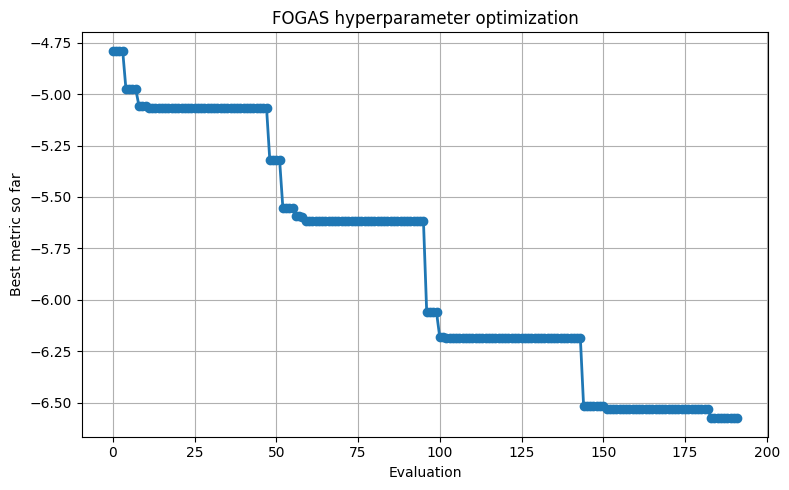

In [ ]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 3e-4, 1e-3, 3e-3],
        "eta": [1e-5, 3e-5, 1e-4, 3e-4],
        "D_theta": [0.5, 1, 5.0, 10.0, 20.0],
        "rho": [1e-2, 1e-1, 1.0, 10.0],
    },
    num_runs=1,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

In [38]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
    T = 10000,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS:   0%|          | 0/10000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 10000/10000 [00:03<00:00, 2894.31it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^pi(x) =  149.642760 | delta = -4.935724e+01
State 1: V*(x) =  200.000000 | V^pi(x) =  150.290350 | delta = -4.970965e+01

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^pi(x,a) =  148.146332 | delta = -4.886367e+01
(x=0, a=1): Q*(x,a) =  199.000000 | Q^pi(x,a) =  149.787446 | delta = -4.921255e+01
(x=1, a=0): Q*(x,a) =  198.010000 | Q^pi(x,a) =  149.146332 | delta = -4.886367e+01
(x=1, a=1): Q*(x,a) =  200.000000 | Q^pi(x,a) =  150.787446 | delta = -4.921255e+01

Norm diagnostics:
||V^pi - V*||_2 = 7.005131e+01
||Q^pi - Q*||_2 = 9.807684e+01


Solver average return: 6.8446415169999995
Optimal average return: 8.801990020000002
Gap: 1.9573485030000022


# Funky Features

## Definition

**Feature Map**

The MDP follows the **Linear MDP assumption**, where both the reward and transition dynamics are linear in a known feature map $ \phi(x,a) $.

The feature representation is defined as:
$$
\phi(x,a) = 2 *
\begin{bmatrix}
1 \\
x \\
a
\end{bmatrix}
\in \mathbb{R}^3.
$$

**Reward Function**

The reward function is a linear combination of the feature vector:
$$
r(x,a) = \phi(x,a)^\top \omega,
$$
with the weight vector
$$
\omega = \frac{1}{2}
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}.
$$

**Transition Function**

The transition model is also linear in the features.
We define a collection of transition weight vectors $ \psi(x') $ such that
$$
p(x'|x,a) = \phi(x,a)^\top \psi(x').
$$

Specifically, the weights are:
$$
\psi(0) = \frac{1}{2}
\begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}, \quad
\psi(1) = \frac{1}{2}
\begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}.
$$

## Testing

In [2]:
states_2d = torch.arange(2, dtype=torch.long)
actions_2d = torch.arange(2, dtype=torch.long)

gamma_2d = 0.99
x_0 = 0

def phi(state, action):
    return 2.0 * tensor64([1.0, float(state), float(action)])

omega = tensor64([0.0, 0.5, 0.5])

psi = {
    0: 0.5 * tensor64([1.0, 0.0, -1.0]),
    1: 0.5 * tensor64([0.0, 0.0, 1.0]),
}

mdp = DiscreteMDP(
    states=states_2d,
    actions=actions_2d,
    gamma=gamma_2d,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
)

planner = Planner(mdp)

RuntimeError: Expected all tensors to be on the same device, but got mat is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmv_)

### Empirical

In [45]:
dataset_path = DATASETS_DIR / "2states.csv"

solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(dataset_path),
    print_params=True,
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 5,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/2states.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     3.4641
Num states N:             2
Num actions A:            2
Feature dim d:            3
Discount γ:               0.99
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      2776.5385579171098
T (iterations):                2777

FOGAS Hyperparameters
---------------------
alpha:                        0.000037
rho:                            809.864260
eta:                            0.000004
D_theta:                    17.320508
beta (ridge):             0.001440
D_pi (derived):           1.791121




In [46]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [3e-5, 1e-4, 3e-4, 1e-3, 3e-3],
        "eta": [3e-6, 1e-5, 3e-5, 1e-4, 3e-4],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=2,
    plot=True,
    print_summary=True,
    progress=True,
)

alpha_star_e = summary_e["best_params"]["alpha"]
rho_star_e = summary_e["best_params"]["rho"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]

FOGAS hyperopt:   0%|          | 0/625 [00:00<?, ?candidate/s]

FOGAS hyperopt:   2%|▏         | 14/625 [00:27<19:43,  1.94s/candidate, stage=grid, metric=-3.62, best=-3.91]


KeyboardInterrupt: 

In [ ]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    rho=rho_star_e,
    D_theta=D_theta_star_e,
    T = 20000,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS:   0%|          | 0/556 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 556/556 [00:03<00:00, 150.61it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  199.000000 | V^π(x) =  199.000000 | Δ =  1.193712e-12
State 1: V*(x) =  200.000000 | V^π(x) =  200.000000 | Δ =  1.193712e-12

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  197.010000 | Q^π(x,a) =  197.010000 | Δ =  1.193712e-12
(x=0, a=1): Q*(x,a) =  199.000000 | Q^π(x,a) =  199.000000 | Δ =  1.193712e-12
(x=1, a=0): Q*(x,a) =  198.010000 | Q^π(x,a) =  198.010000 | Δ =  1.193712e-12
(x=1, a=1): Q*(x,a) =  200.000000 | Q^π(x,a) =  200.000000 | Δ =  1.193712e-12

Norm diagnostics:
||V^π - V*||_2 = 1.688163e-12
||Q^π - Q*||_2 = 2.387424e-12



========== FINAL REWARD COMPARISON ==========

J*(π*)   = 1.990000
J(π_FOGAS) = 1.990000
Gap (J* − J) = -1.199041e-14


